In [11]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [12]:
SETTINGS = {"epoch": 0, "n": 100, "split":"test" }
  
CONDITIONS = [
    "3mod_s126_sd",
]

DATA = [
    "form_50_35_15_cgc_0_20",
    "form_50_35_15_cgc_1_20",
    "form_50_35_15_cgc_2_20",
    "form_50_35_15_cgc_3_20"
]


In [13]:
def plot_hue_histogram(
    metrics: dict,
    title: str = '',
    value: float = 0.85,
    saturation_boost: float = 1.4,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Trace l'histogramme des teintes à partir du dict retourné par compute_hue_metrics.
    Si ax est fourni, trace dans cet axe (utile pour les grilles multi-panneaux).
    """
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(7, 4))
 
    hues      = metrics['hues']
    labels    = metrics['labels']
    per_cat   = metrics['per_cat']
 
    for cat, info in per_cat.items():
        h      = hues[labels == cat]
        color  = boost_color(
            np.array(colorsys.hsv_to_rgb(info['mean_hue'] / 360, 1.0, 1.0)),
            value=value,
            saturation_boost=saturation_boost,
        )
        ax.hist(h, bins=36, range=(0, 360), color=color,
                alpha=0.6, label=info['name'], edgecolor='none')
        ax.axvline(info['mean_hue'], color=color, linewidth=2, linestyle='--')
 
    ax.set_xlabel('Teinte H (°)', fontsize=10)
    ax.set_ylabel("Nb d'exemples", fontsize=10)
    ax.set_xlim(0, 360)
    ax.set_xticks(range(0, 361, 60))
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, framealpha=0.6)
 
    subtitle = (
        f"KW H={metrics['kruskal_H']:.1f}  p={metrics['kruskal_p']:.1e}  "
        f"LDA={metrics['lda_score']:.0%}"
    )
    ax.set_title(f"{title}\n{subtitle}" if title else subtitle, fontsize=9)
 
    if show:
        plt.tight_layout()
        plt.show()
 
    return ax


In [14]:
def run_all(
    conditions: list[str],
    data_list: list[str],
    cat_names: dict | None = None,
    value: float = 0.75,
    saturation_boost: float = 1.8,
    plot_grid: bool = True,
    verbose: bool = True,
) -> dict[tuple[str, str], dict]:
    """
    Itère sur toutes les combinaisons (condition, data),
    calcule les métriques et trace une grille de figures.
 
    Parameters
    ----------
    conditions       : liste des identifiants de condition
    data_list        : liste des identifiants de données
    cat_names        : dict {int: str} des noms de catégories
    value            : luminosité pour boost_color
    saturation_boost : saturation pour boost_color
    plot_grid        : si True, affiche une grille n_conditions × n_data
    verbose          : si True, affiche les métriques dans la console
 
    Returns
    -------
    results : dict[(condition, data)] = dict de métriques
    """
    n_cond = len(conditions)
    n_data = len(data_list)
    results: dict[tuple[str, str], dict] = {}
 
    if plot_grid:
        fig, axes = plt.subplots(
            n_cond, n_data,
            figsize=(4 * n_data, 3.5 * n_cond),
            squeeze=False,
        )
 
    for i, condition in enumerate(conditions):
        for j, data in enumerate(data_list):
            key   = (condition, data)
            title = f"{condition}\n{data}"
 
            if verbose:
                print(f"\n{'='*60}")
                print(f"  Condition : {condition}")
                print(f"  Data      : {data}")
                print(f"{'='*60}")
 
            # Chargement
            _, colors_np, labels = get_colors_labels_per_condition(condition, data, SETTINGS)
 
            # Métriques
            m = compute_hue_metrics(colors_np, labels, cat_names=cat_names)
            results[key] = m
 
            # Affichage console
            if verbose:
                print(f"  Kruskal-Wallis : H={m['kruskal_H']:.1f}   p={m['kruskal_p']:.2e}")
                print(f"  Précision LDA  : {m['lda_score']:.2%}")
                for cat, info in m['per_cat'].items():
                    print(
                        f"    {info['name']:12} → "
                        f"moyenne={info['mean_hue']:.1f}°  "
                        f"std={info['std_hue']:.1f}°"
                    )
 
            # Visualisation dans la grille
            if plot_grid:
                plot_hue_histogram(
                    m,
                    title=title,
                    value=value,
                    saturation_boost=saturation_boost,
                    ax=axes[i][j],
                )
 
    if plot_grid:
        fig.tight_layout()
        plt.show()
 
    return results


In [15]:
def print_summary(results: dict[tuple[str, str], dict]) -> None:
    """Affiche un tableau récapitulatif des métriques agrégées."""
    header = f"{'Condition':<25} {'Data':<30} {'KW H':>8} {'p':>10} {'LDA':>7}"
    print("\n" + header)
    print("-" * len(header))
    for (condition, data), m in results.items():
        print(
            f"{condition:<25} {data:<30} "
            f"{m['kruskal_H']:>8.1f} {m['kruskal_p']:>10.2e} "
            f"{m['lda_score']:>7.2%}"
        )



  Condition : 3mod_s126_sd
  Data      : form_50_35_15_cgc_0_20


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_s126_sd_form_50_35_15_cgc_0_20/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_s126_sd_form_50_35_15_cgc_0_20/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


  Kruskal-Wallis : H=17.3   p=1.75e-04
  Précision LDA  : 70.00%
    diamond      → moyenne=311.5°  std=65.5°
    egg          → moyenne=157.1°  std=63.7°
    triangle     → moyenne=90.5°  std=56.4°

  Condition : 3mod_s126_sd
  Data      : form_50_35_15_cgc_1_20


...

  Kruskal-Wallis : H=27.6   p=9.93e-07
  Précision LDA  : 73.00%
    diamond      → moyenne=329.1°  std=64.5°
    egg          → moyenne=207.8°  std=50.1°
    triangle     → moyenne=54.0°  std=59.9°

  Condition : 3mod_s126_sd
  Data      : form_50_35_15_cgc_3_20


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_s126_sd_form_50_35_15_cgc_3_20/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_s126_sd_form_50_35_15_cgc_3_20/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


  Kruskal-Wallis : H=44.3   p=2.35e-10
  Précision LDA  : 80.00%
    diamond      → moyenne=283.1°  std=50.8°
    egg          → moyenne=199.3°  std=53.6°
    triangle     → moyenne=38.9°  std=53.4°


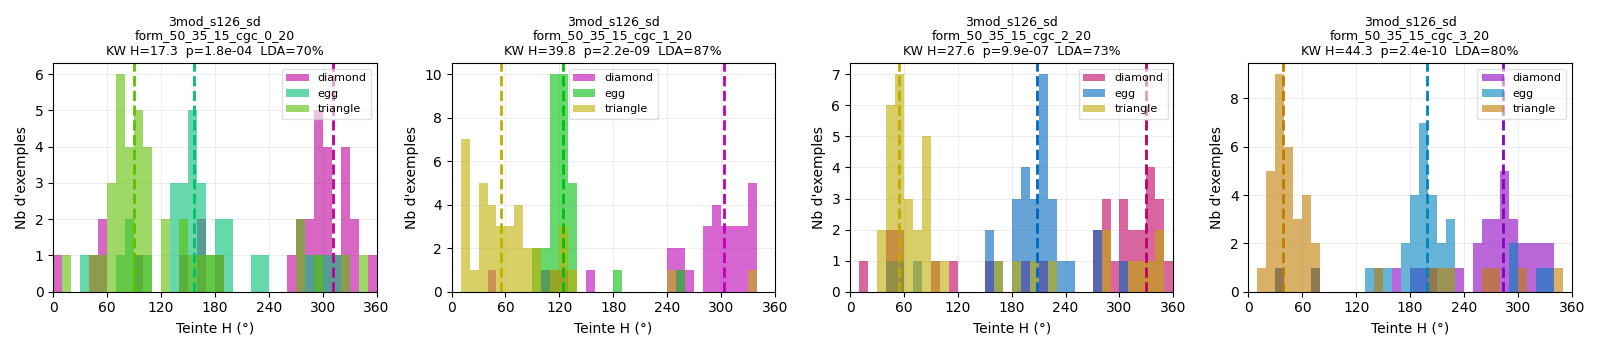


Condition                 Data                               KW H          p     LDA
------------------------------------------------------------------------------------
3mod_s126_sd              form_50_35_15_cgc_0_20             17.3   1.75e-04  70.00%
3mod_s126_sd              form_50_35_15_cgc_1_20             39.8   2.24e-09  87.00%
3mod_s126_sd              form_50_35_15_cgc_2_20             27.6   9.93e-07  73.00%
3mod_s126_sd              form_50_35_15_cgc_3_20             44.3   2.35e-10  80.00%


In [16]:
results = run_all(
        conditions=CONDITIONS,
        data_list=DATA,
        cat_names=CAT_NAMES,
        value=0.75,
        saturation_boost=1.8,
        plot_grid=True,
        verbose=True,
    )
print_summary(results)


In [17]:
import numpy as np

# 1. Regroupement de tes datasets dans un dictionnaire global
datasets = {
    0: {
        0: [1/3, 1/3, 1/3],  # diamant
        1: [1/3, 1/3, 1/3],  # oeuf
        2: [1/3, 1/3, 1/3],  # triangle
    },
    1: {
        0: [0.3, 0.3, 0.4],  # diamant
        1: [0.8, 0.1, 0.1],  # oeuf
        2: [0.2, 0.7, 0.1],  # triangle
    },
    2: {
        0: [0.3, 0.3, 0.4],  # diamant
        1: [0.1, 0.1, 0.8],  # oeuf
        2: [0.2, 0.7, 0.1],  # triangle
    },
    3: {
        0: [0.2, 0.2, 0.6],  # diamant
        1: [0.1, 0.1, 0.8],  # oeuf
        2: [0.2, 0.7, 0.1],  # triangle
    }
}

def get_shape_color_associations(all_datasets):
    # Mapping entre l'index du tableau [vert, rouge, bleu] et ton code couleur
    # Index 0 = Vert (120), Index 1 = Rouge (0), Index 2 = Bleu (240)
    color_map = {0: 120, 1: 0, 2: 240}
    
    result = {}
    
    for dataset_id, shapes in all_datasets.items():
        result[dataset_id] = {}
        
        for shape_id, probs in shapes.items():
            # On récupère l'index de la probabilité maximale
            max_prob_index = np.argmax(probs)
            # On convertit cet index en ton code couleur (0, 120 ou 240)
            result[dataset_id][shape_id] = color_map[max_prob_index]
            
    return result

# Exécution de la fonction
associations = get_shape_color_associations(datasets)
print(associations)

{0: {0: 120, 1: 120, 2: 120}, 1: {0: 240, 1: 120, 2: 0}, 2: {0: 240, 1: 240, 2: 0}, 3: {0: 240, 1: 240, 2: 0}}


In [18]:
def analyze_movement(baseline, expected, observed):
    # 1. Calcul de la distance la plus courte et du sens de la baseline vers l'expected
    diff_target = (expected - baseline) % 360
    if diff_target > 180:
        # Le chemin le plus court est dans le sens anti-horaire
        shortest_target_dist = 360 - diff_target
        direction = -1
    else:
        # Le chemin le plus court est dans le sens horaire
        shortest_target_dist = diff_target
        direction = 1
        
    # 2. Calcul du déplacement de la couleur observée par rapport à la baseline
    # On regarde de combien on a bougé dans la direction définie par le point cible
    diff_observed = (observed - baseline) % 360
    
    if direction == 1:
        # Si on devait aller dans le sens horaire
        if diff_observed > 180:
            # L'observed est parti à l'envers (sens anti-horaire)
            movement = diff_observed - 360
        else:
            movement = diff_observed
    else:
        # Si on devait aller dans le sens anti-horaire
        if diff_observed < 180:
            # L'observed est parti à l'envers (sens horaire)
            movement = -diff_observed
        else:
            movement = 360 - diff_observed

    # 3. Vérification du dépassement
    # Il y a dépassement si le mouvement est dans le bon sens ET plus grand que la distance visée
    overshot = movement > shortest_target_dist
    
    return {
        'movement_deg': round(movement, 2),
        'target_distance_deg': round(shortest_target_dist, 2),
        'overshot': overshot
    }

In [19]:
def extract_dataset_id(s: str) -> int:
    """Extrait l'entier qui suit 'cgc_' dans une chaîne."""
    marker = "cgc_"
    idx = s.index(marker)
    start = idx + len(marker)
    end = s.index("_", start)
    return int(s[start:end])

def compute_all_differences(results, datasets_prob, baseline_id=0):
    associations = get_shape_color_associations(datasets_prob)
    
    # Récupération de la baseline (mesures du dataset 0)
    baseline_data = None
    for key, value in results.items():
        if extract_dataset_id(key[1]) == baseline_id:
            baseline_data = value['per_cat']
            break
            
    final_analysis = {}

    for key, value in results.items():
        config_string = key[1]
        dataset_id = extract_dataset_id(config_string)
        if dataset_id is None: continue
            
        observed_data = value['per_cat']
        final_analysis[key] = {}
        
        for shape_id, data in observed_data.items():
            observed_hue = data['mean_hue']
            expected_hue = associations[dataset_id][shape_id]
            baseline_hue = baseline_data[shape_id]['mean_hue']
            
            # Calcul du déplacement et du dépassement
            movement_stats = analyze_movement(baseline_hue, expected_hue, observed_hue)
            
            final_analysis[key][shape_id] = {
                'name': data['name'],
                'observed_hue': round(observed_hue, 2),
                'expected_hue': expected_hue,
                'baseline_hue': round(baseline_hue, 2),
                'movement_towards_target': movement_stats['movement_deg'],
                'target_total_distance': movement_stats['target_distance_deg'],
                'is_overshot': movement_stats['overshot']
            }
            
    return final_analysis

In [20]:
compute_all_differences(results, datasets)

{('3mod_s126_sd',
  'form_50_35_15_cgc_0_20'): {0: {'name': 'diamond',
   'observed_hue': 311.5,
   'expected_hue': 120,
   'baseline_hue': 311.5,
   'movement_towards_target': 0.0,
   'target_total_distance': 168.5,
   'is_overshot': False}, 1: {'name': 'egg',
   'observed_hue': 157.1,
   'expected_hue': 120,
   'baseline_hue': 157.1,
   'movement_towards_target': -0.0,
   'target_total_distance': 37.1,
   'is_overshot': False}, 2: {'name': 'triangle',
   'observed_hue': 90.46,
   'expected_hue': 120,
   'baseline_hue': 90.46,
   'movement_towards_target': 0.0,
   'target_total_distance': 29.54,
   'is_overshot': False}},
 ('3mod_s126_sd',
  'form_50_35_15_cgc_1_20'): {0: {'name': 'diamond',
   'observed_hue': 303.22,
   'expected_hue': 240,
   'baseline_hue': 311.5,
   'movement_towards_target': 8.27,
   'target_total_distance': 71.5,
   'is_overshot': False}, 1: {'name': 'egg',
   'observed_hue': 123.98,
   'expected_hue': 120,
   'baseline_hue': 157.1,
   'movement_towards_target':